In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
DATA_FILE = r"/home/ltimindtree/Documents/personal/code/AIMLCZG628T/datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset.csv"

dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description
datetime,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,0.382638,90.6454,26.8508,238.852,122.6640,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,-0.273216,90.7978,26.8639,227.943,122.3380,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,0.382638,90.7730,26.8603,223.486,121.3380,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,0.054711,90.8424,26.8616,244.904,121.6640,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,0.054711,69.6731,24.1046,230.729,32.9562,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,0.054711,69.6959,24.1020,233.443,32.0000,0.0,No Anomaly


## Univariate Analysis

In [3]:
def plot_numerical_distribution_plot(df, title=None, stat="count"):
    fig, axs = plt.subplots(4, 2, figsize=(20, 20))
    plt.subplots_adjust(hspace=0.3)

    if title: plt.suptitle(title, fontsize=20)

    sns.histplot(data=df, x="Accelerometer1RMS", kde=True, ax=axs[0, 0], hue="description", stat=stat)
    axs[0, 0].set_title("Distribution of Accelerometer1RMS")

    sns.histplot(data=df, x="Accelerometer2RMS", kde=True, ax=axs[0, 1], hue="description", stat=stat)
    axs[0, 1].set_title("Distribution of Accelerometer2RMS")

    sns.histplot(data=df, x="Current", kde=True, ax=axs[1, 0], hue="description", stat=stat)
    axs[1, 0].set_title("Distribution of Current")

    sns.histplot(data=df, x="Voltage", kde=True, ax=axs[1, 1], hue="description", stat=stat)
    axs[1, 1].set_title("Distribution of Voltage")

    sns.histplot(data=df, x="Pressure", kde=True, ax=axs[2, 0], hue="description", stat=stat)
    axs[2, 0].set_title("Distribution of Pressure")

    sns.histplot(data=df, x="Volume Flow RateRMS", kde=True, ax=axs[2, 1], hue="description", stat=stat)
    axs[2, 1].set_title("Distribution of Volume Flow RateRMS")

    sns.histplot(data=df, x="Temperature", kde=True, ax=axs[3, 0], hue="description", stat=stat)
    axs[3, 0].set_title("Distribution of Temperature")

    sns.histplot(data=df, x="Thermocouple", kde=True, ax=axs[3, 1], hue="description", stat=stat)
    axs[3, 1].set_title("Distribution of Thermocouple")

    plt.tight_layout()
    plt.show()

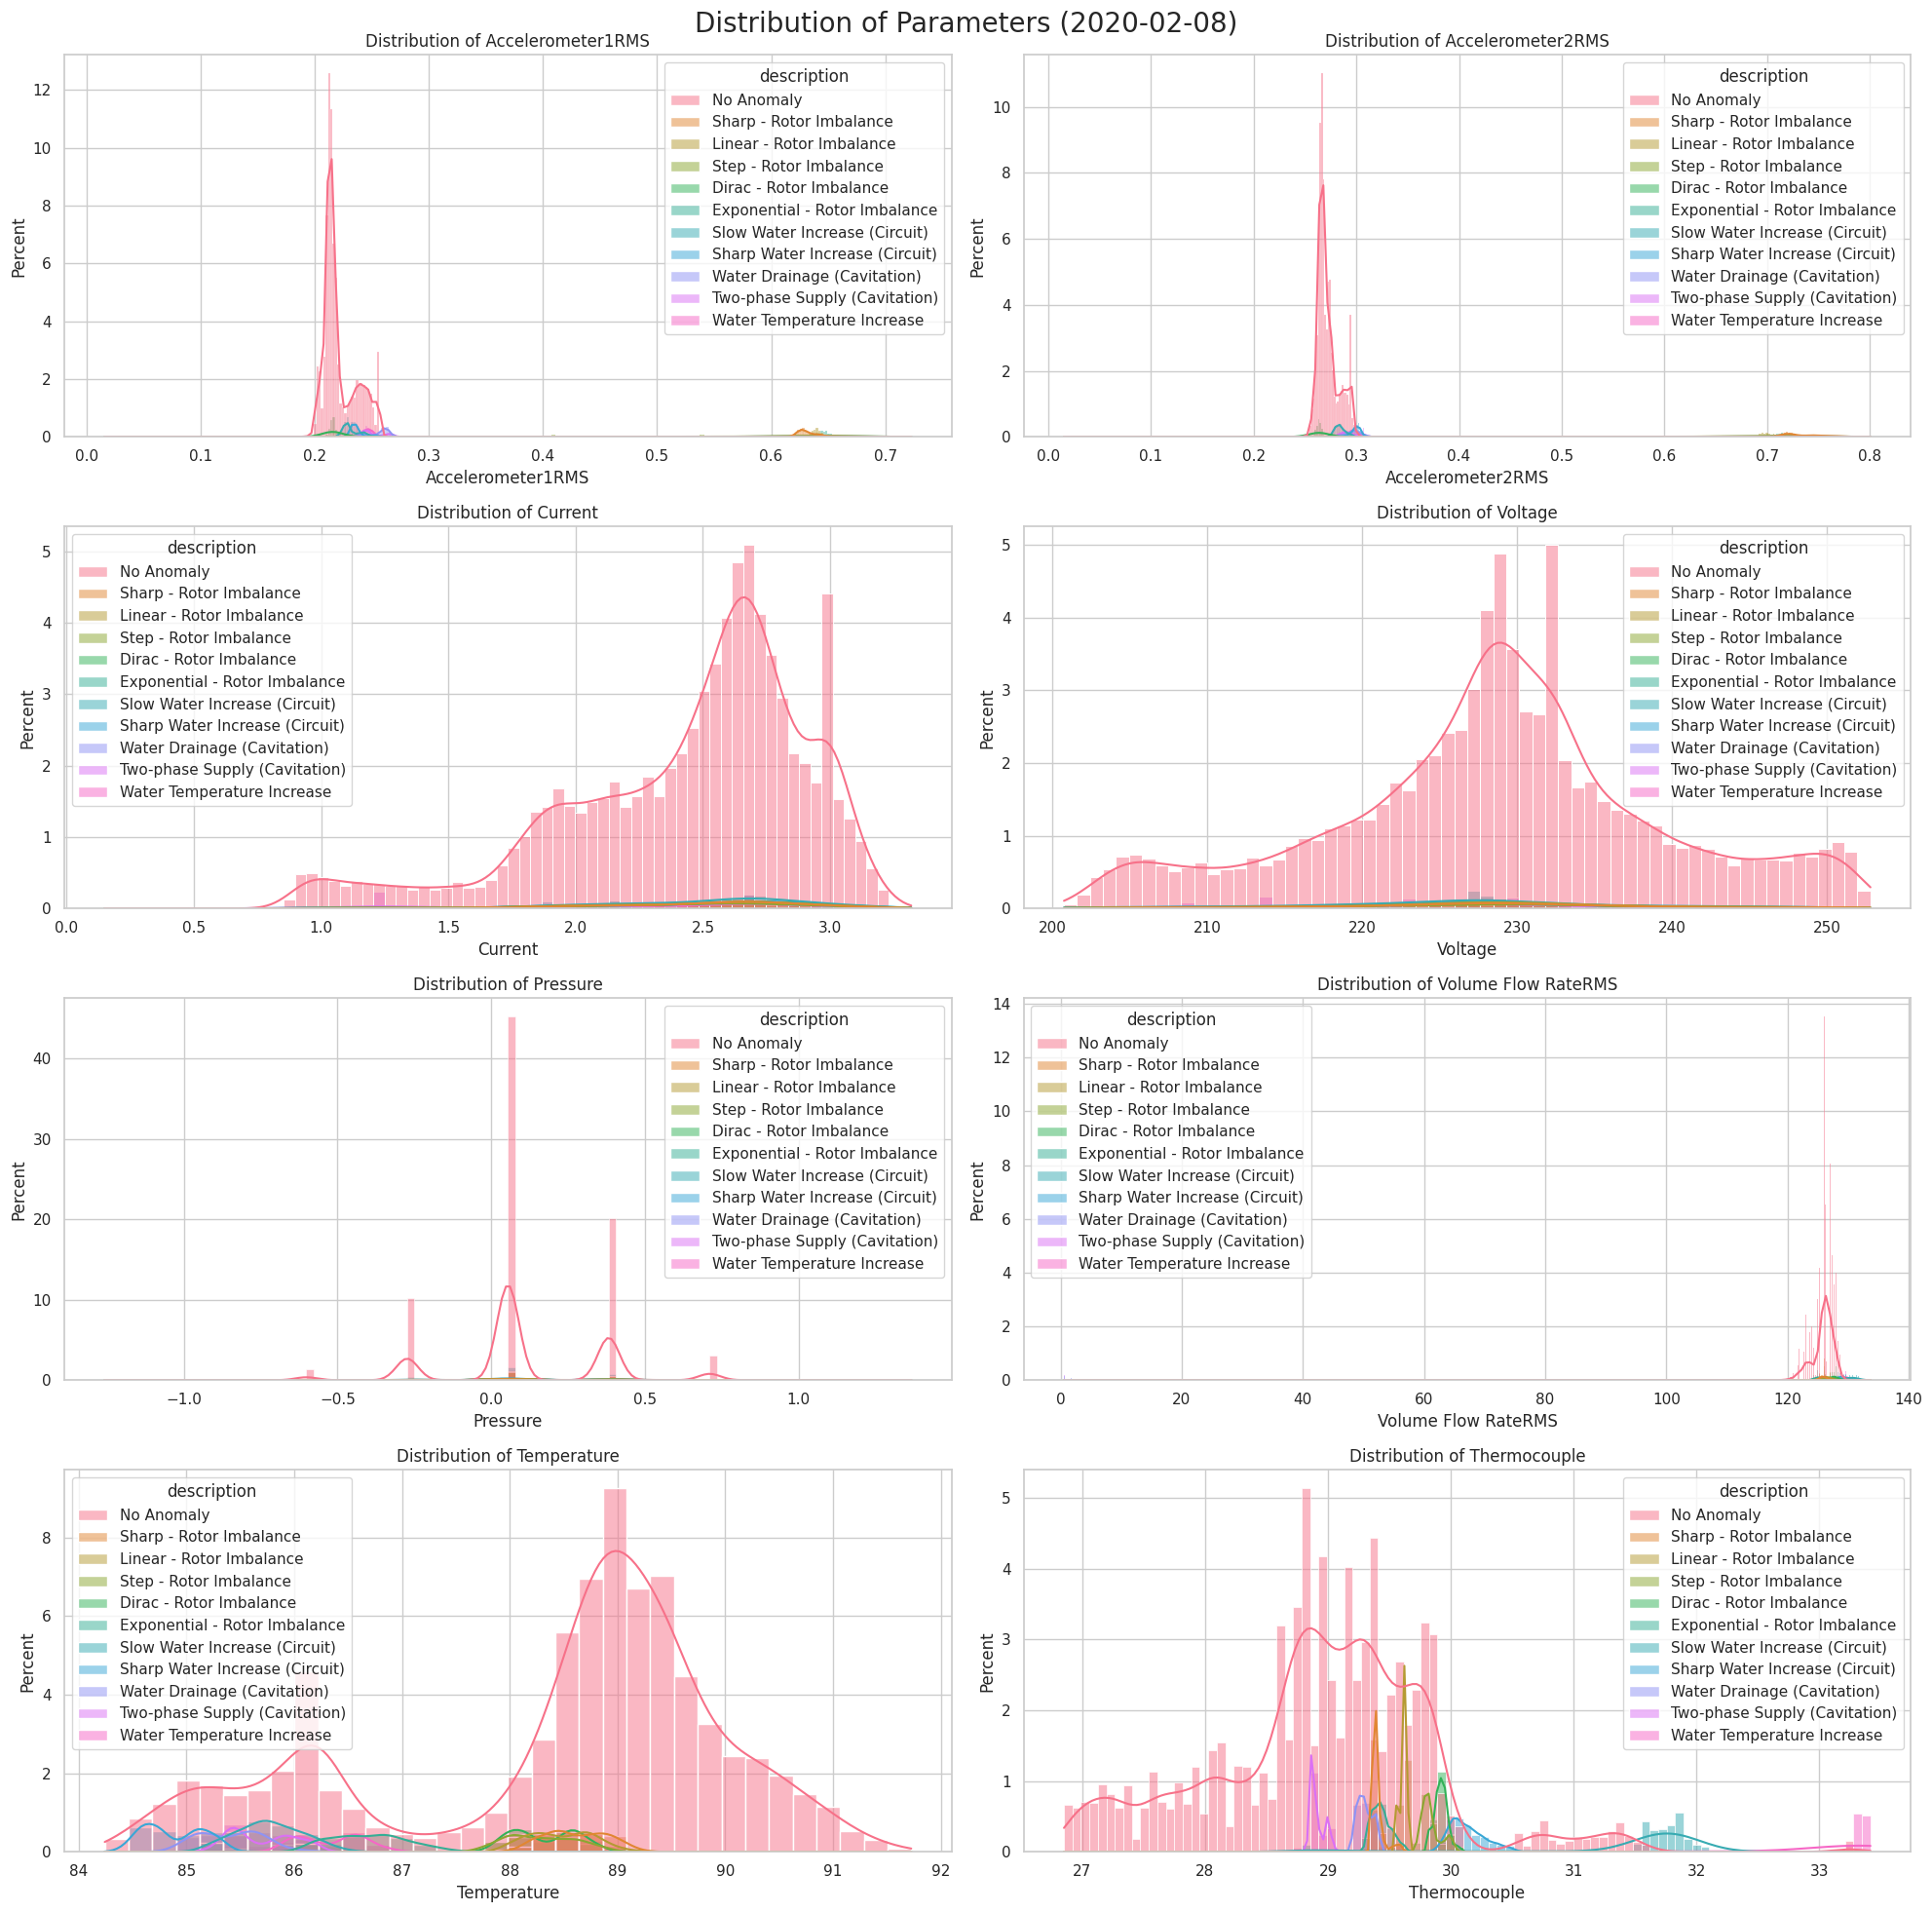

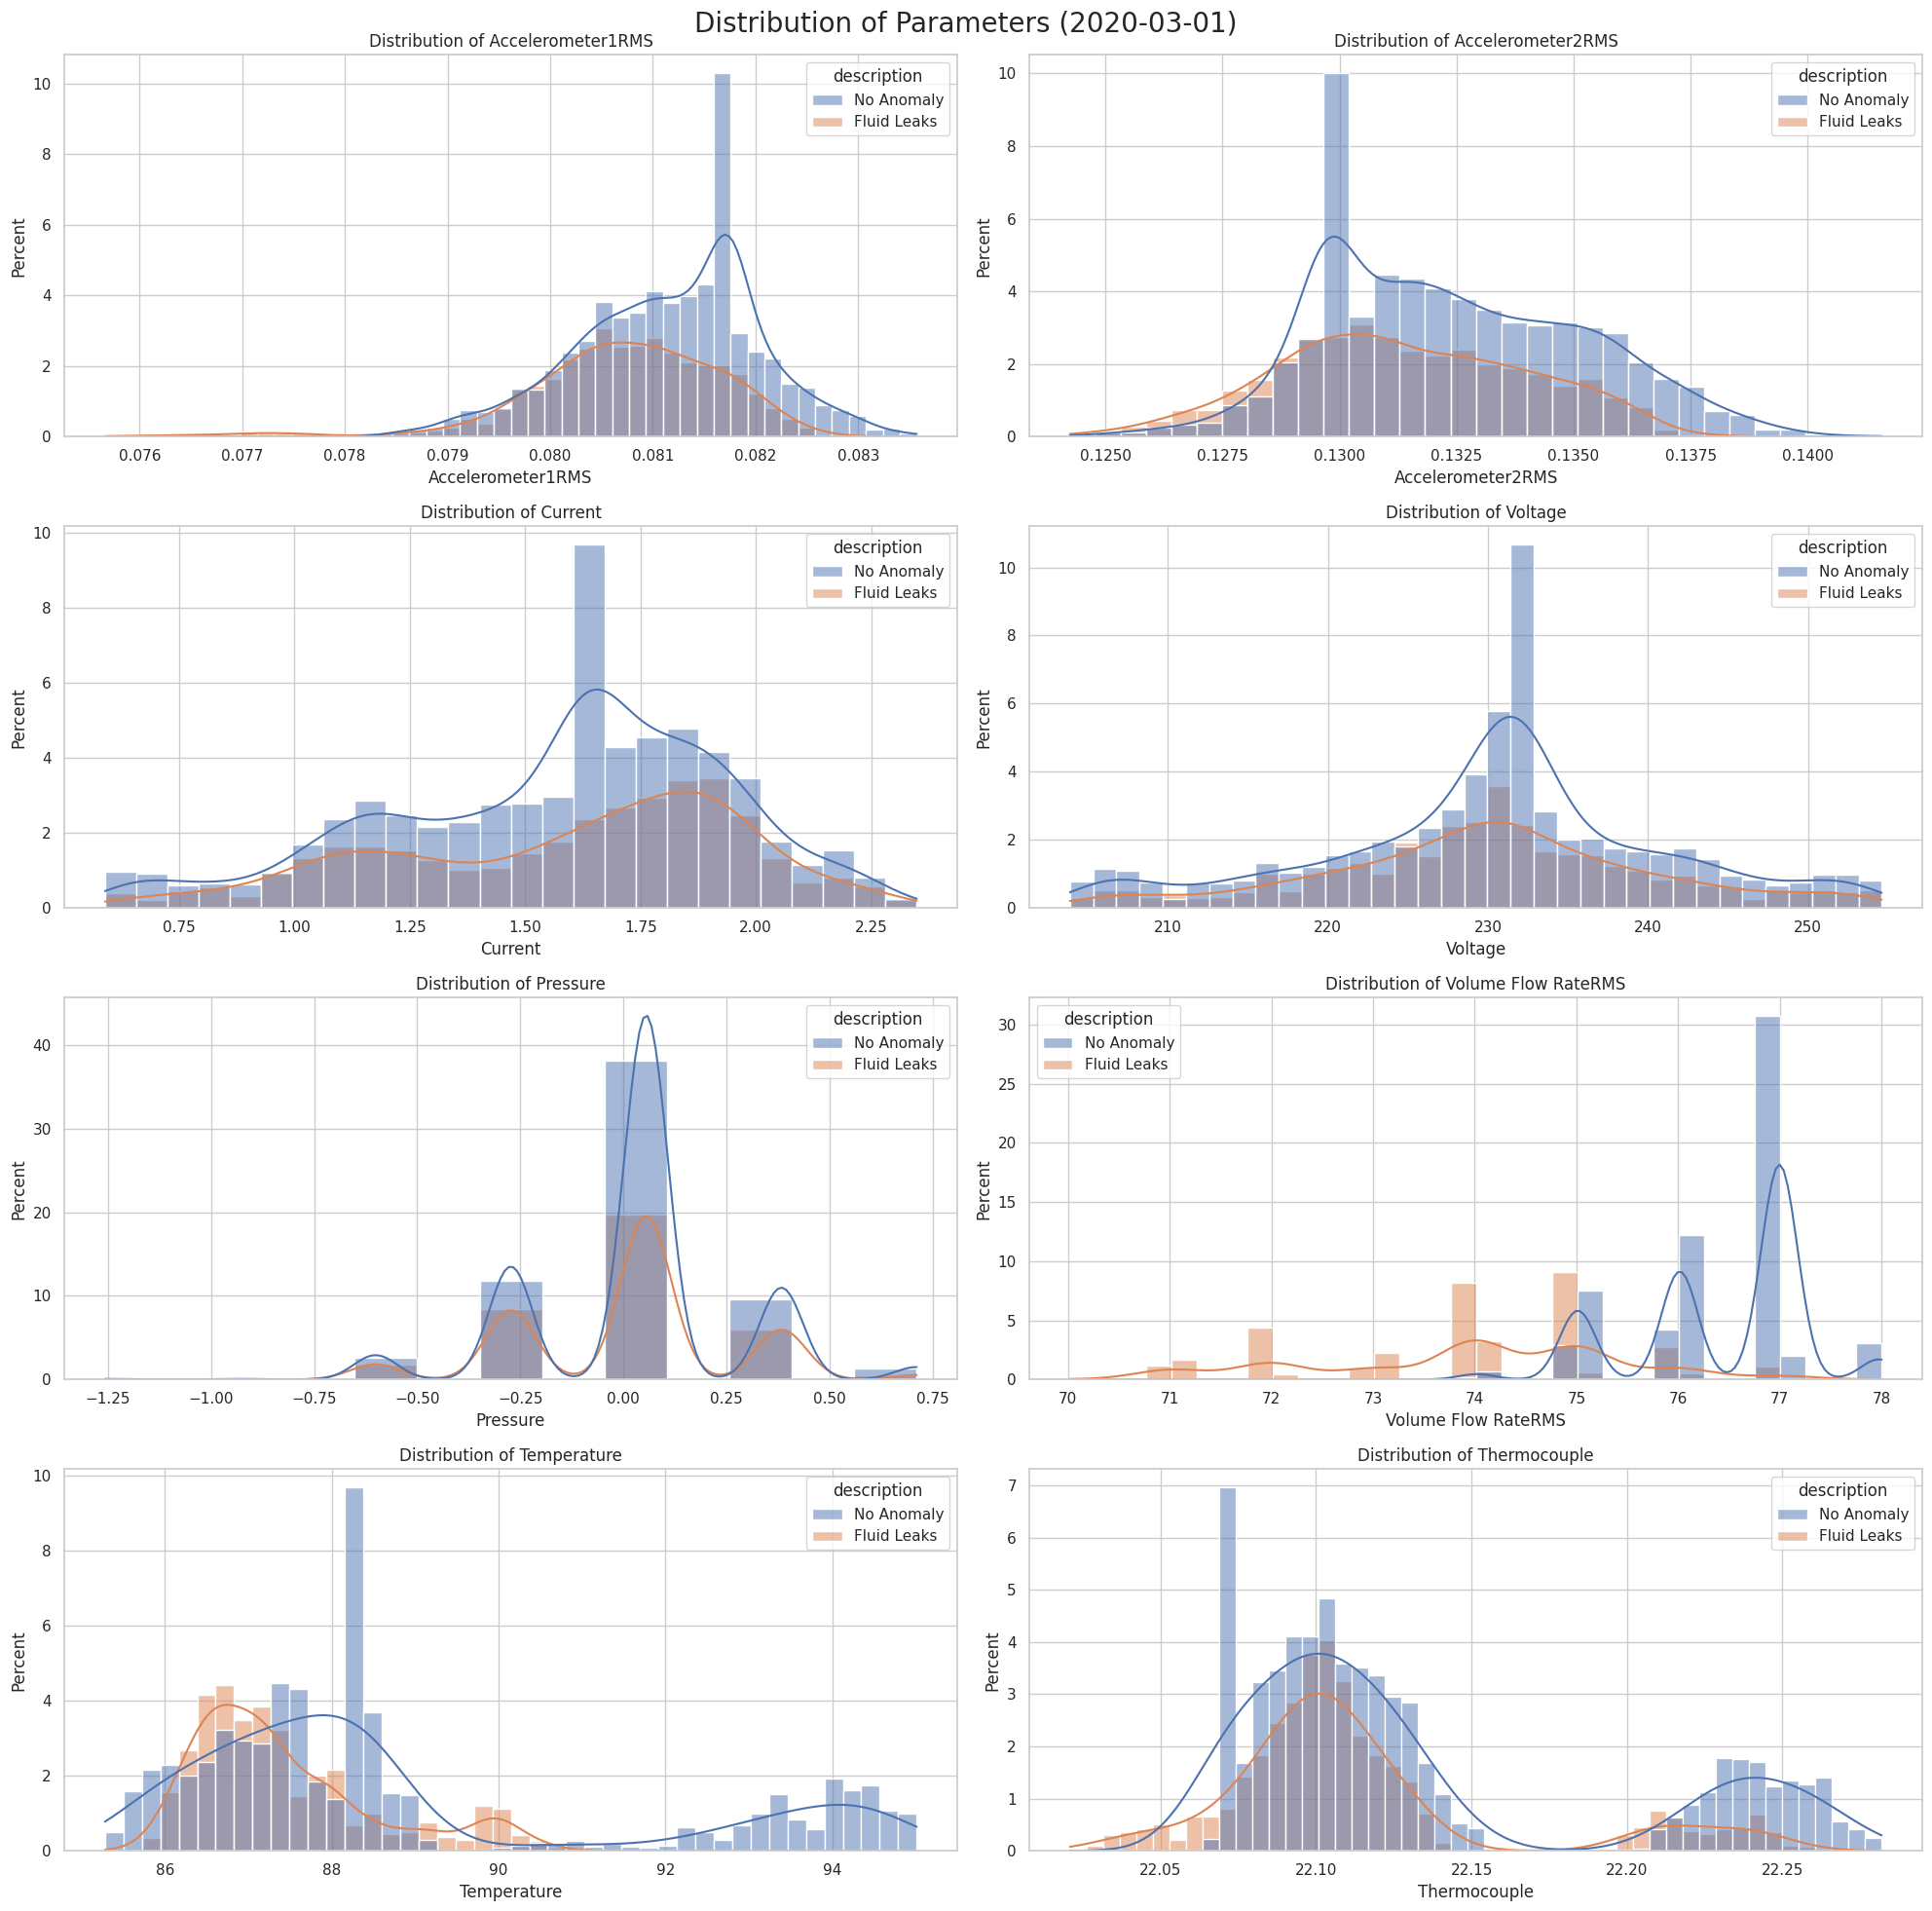

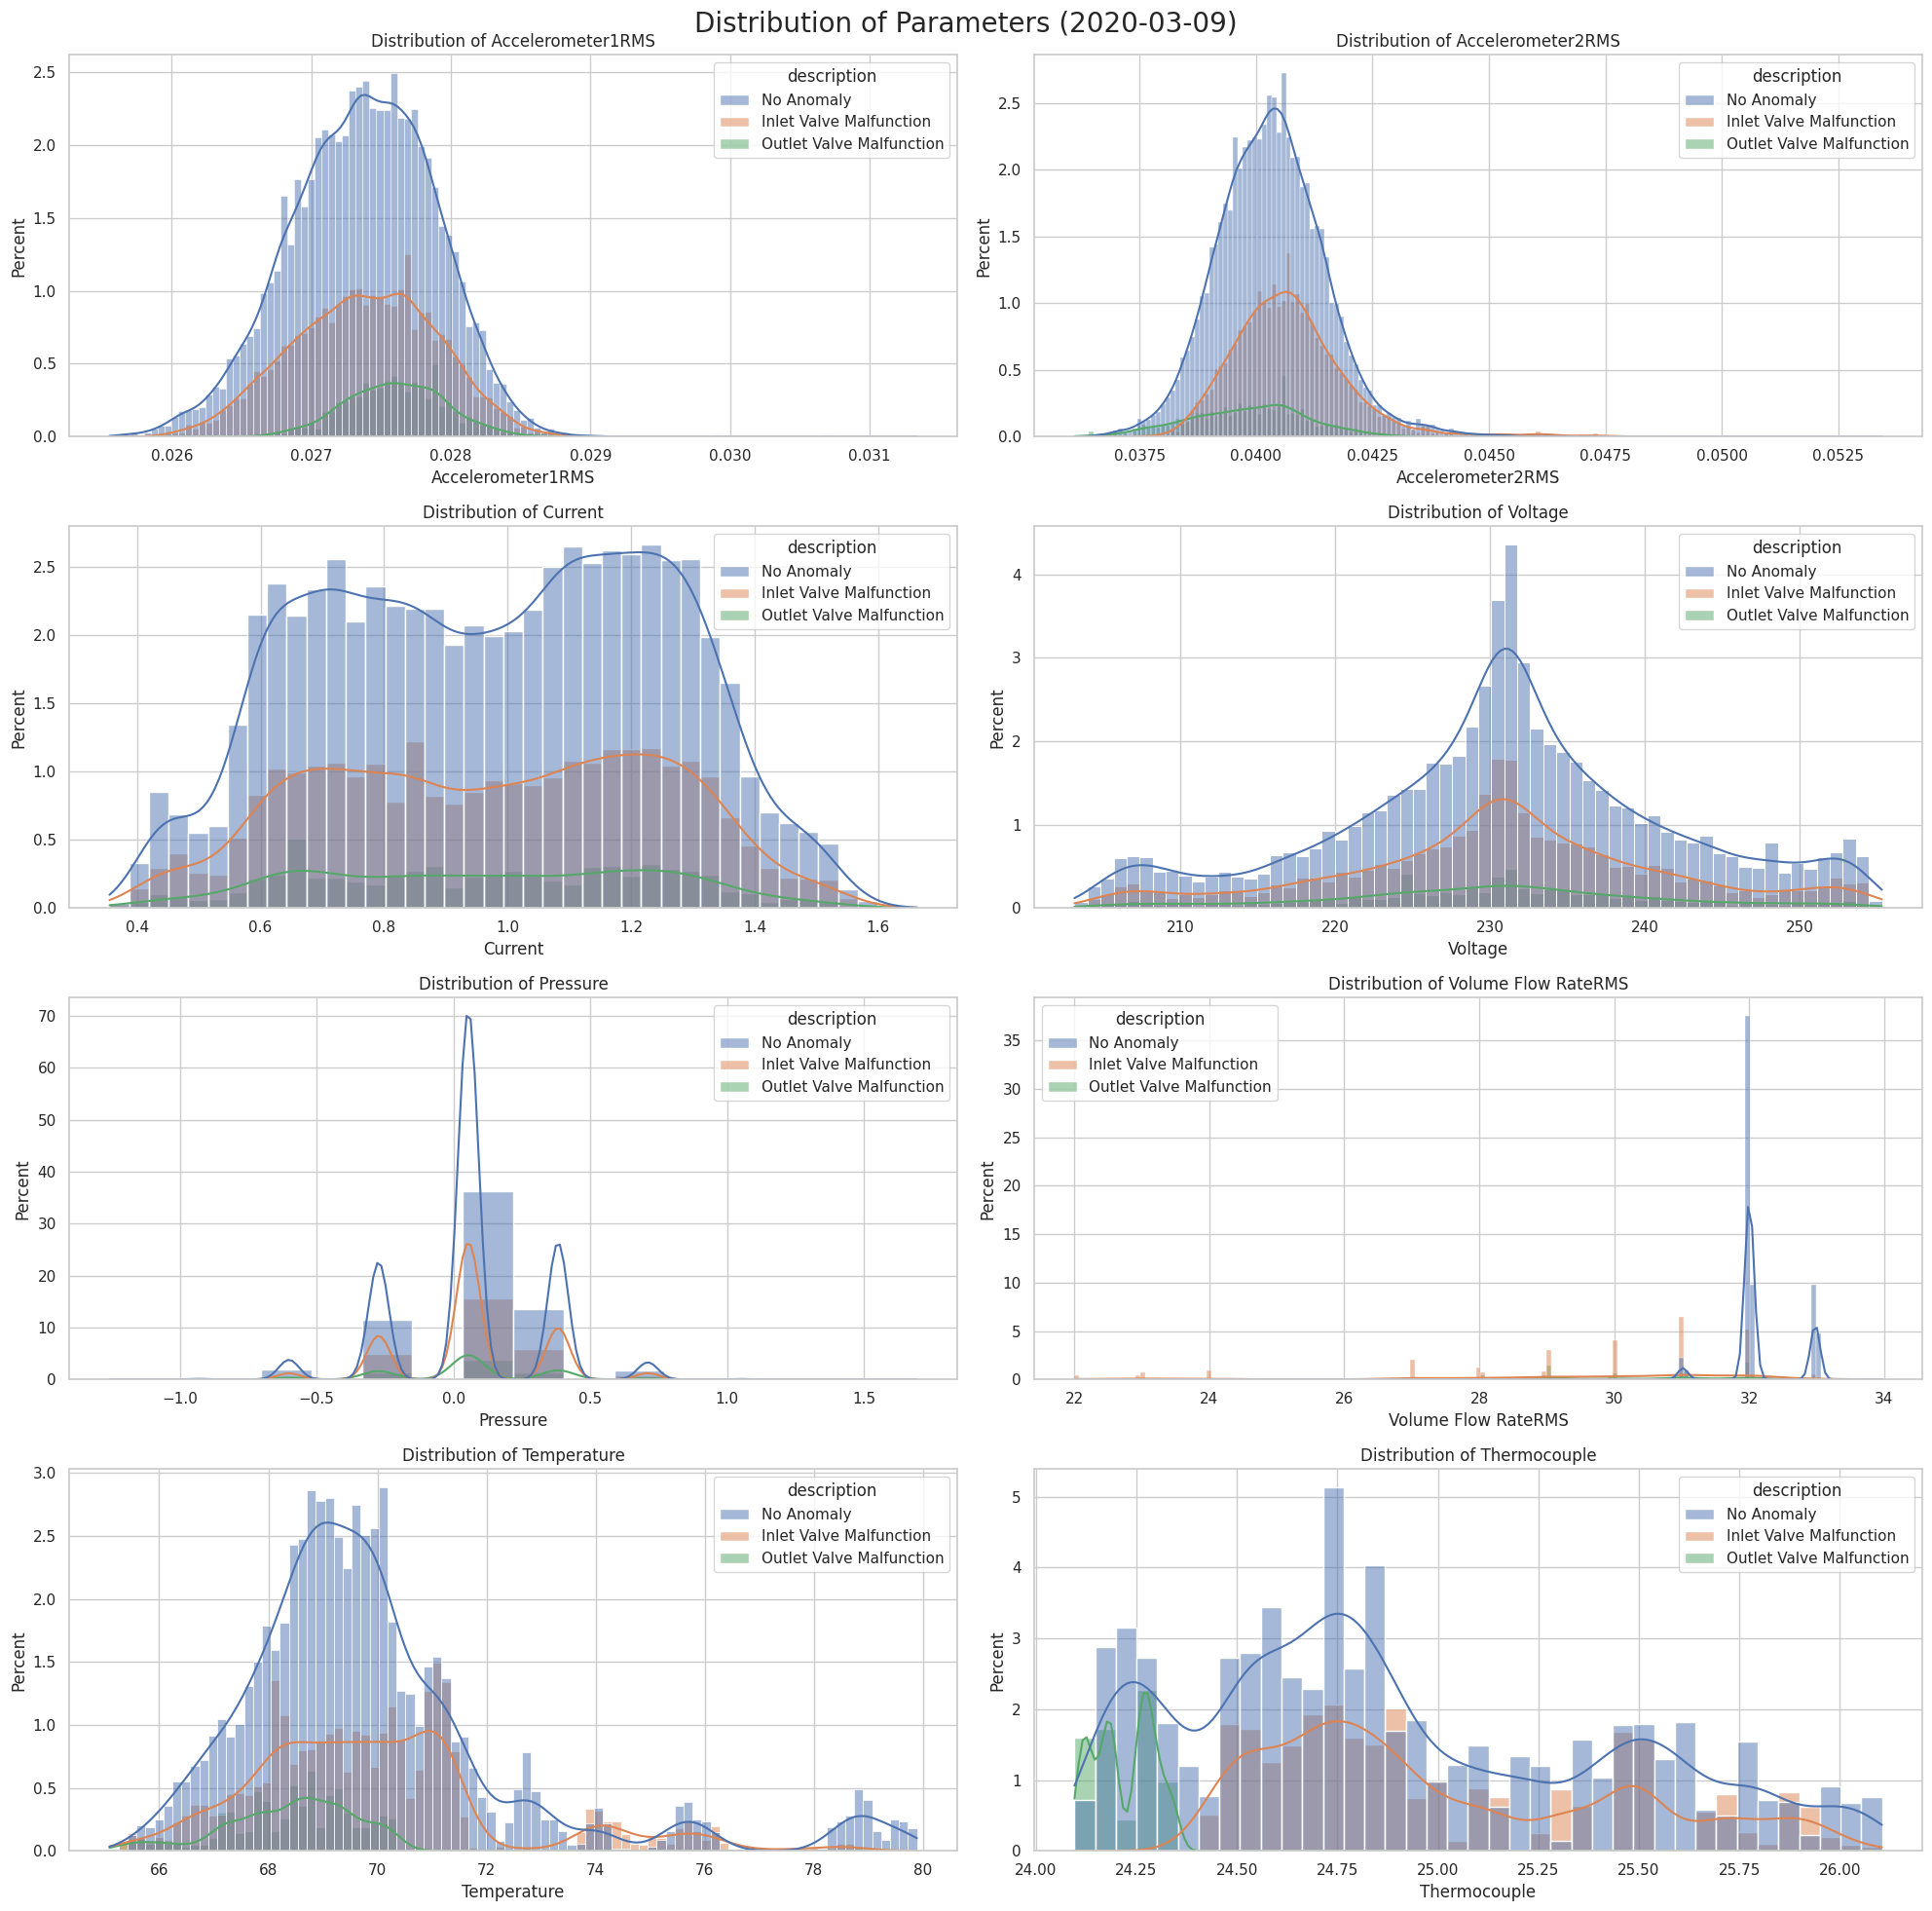

In [4]:
plot_numerical_distribution_plot(dataframe["2020-02-08 00:00:00":"2020-02-08 23:59:59"], title="Distribution of Parameters (2020-02-08)", stat="percent")
plot_numerical_distribution_plot(dataframe["2020-03-01 00:00:00":"2020-03-01 23:59:59"], title="Distribution of Parameters (2020-03-01)", stat="percent")
plot_numerical_distribution_plot(dataframe["2020-03-09 00:00:00":"2020-03-09 23:59:59"], title="Distribution of Parameters (2020-03-09)", stat="percent")

In [5]:
def plot_categorical_distribution_plot(dataframe, column_name, title=None):
    """
    Plots the distribution of a categorical column with counts on top of bars.

    Args:
        dataframe (pd.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
        title (str, optional): The title of the plot. Defaults to None.
    """
    plt.figure(figsize=(15, 6)) # Adjusted figure size for better readability
    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    # Create the countplot
    ax = sns.countplot(y=column_name, data=dataframe, order=dataframe[column_name].value_counts().index, palette='viridis', stat="percent")

    # Add count labels on top of each bar
    for p in ax.patches:
        width = p.get_width()    # Get the width of the bar (which is the count)
        plt.text(width + 0.5,     # Set the x position of the text slightly to the right of the bar
                 p.get_y() + p.get_height() / 2, # Set the y position at the middle of the bar
                 '{:0.2f}%'.format(width), # Format the count to an integer
                 ha='left', va='center', fontsize=10, color='black') # Text alignment and style

    plt.xlabel('Count', fontsize=12) # Label for x-axis
    plt.ylabel(column_name.replace('_', ' ').title(), fontsize=12) # Formatted label for y-axis
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

/tmp/ipykernel_153113/4003324623.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=column_name, data=dataframe, order=dataframe[column_name].value_counts().index, palette='viridis', stat="percent")


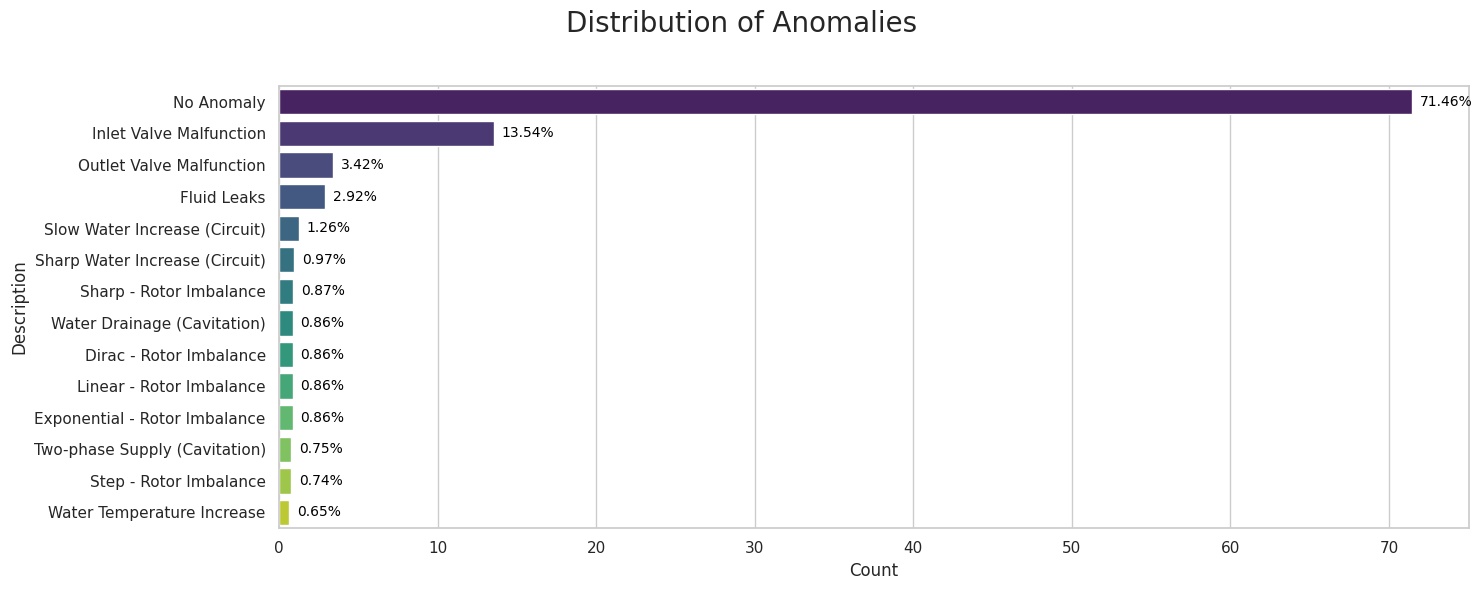

In [6]:
plot_categorical_distribution_plot(dataframe, column_name="description", title="Distribution of Anomalies")

## Bivariate Analysis

In [7]:
def plot_box(df, title=None):
    fig, axs = plt.subplots(8, 1, figsize=(20, 60))
    # plt.subplots_adjust(hspace=0.5)

    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    sns.boxplot(x="Accelerometer1RMS", y="description", data=df, hue="description", ax=axs[0])
    axs[0].set_title("Distribution of Accelerometer1RMS", weight="bold")

    sns.boxplot(x="Accelerometer2RMS", y="description", data=df, hue="description", ax=axs[1])
    axs[1].set_title("Distribution of Accelerometer2RMS", weight="bold")

    sns.boxplot(x="Current", y="description", data=df, hue="description", ax=axs[2])
    axs[2].set_title("Distribution of Current", weight="bold")

    sns.boxplot(x="Voltage", y="description", data=df, hue="description", ax=axs[3])
    axs[3].set_title("Distribution of Voltage", weight="bold")

    sns.boxplot(x="Pressure", y="description", data=df, hue="description", ax=axs[4])
    axs[4].set_title("Distribution of Pressure", weight="bold")

    sns.boxplot(x="Volume Flow RateRMS", y="description", data=df, hue="description", ax=axs[5])
    axs[5].set_title("Distribution of Volume Flow RateRMS", weight="bold")

    sns.boxplot(x="Temperature", y="description", data=df, hue="description", ax=axs[6])
    axs[6].set_title("Distribution of Temperature", weight="bold")

    sns.boxplot(x="Thermocouple", y="description", data=df, hue="description", ax=axs[7])
    axs[7].set_title("Distribution of Thermocouple", weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

def plot_violin(df, title=None):
    fig, axs = plt.subplots(8, 1, figsize=(20, 60))
    # plt.subplots_adjust(hspace=0.5)

    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    sns.violinplot(x="Accelerometer1RMS", y="description", data=df, hue="description", ax=axs[0])
    axs[0].set_title("Distribution of Accelerometer1RMS", weight="bold")

    sns.violinplot(x="Accelerometer2RMS", y="description", data=df, hue="description", ax=axs[1])
    axs[1].set_title("Distribution of Accelerometer2RMS", weight="bold")

    sns.violinplot(x="Current", y="description", data=df, hue="description", ax=axs[2])
    axs[2].set_title("Distribution of Current", weight="bold")

    sns.violinplot(x="Voltage", y="description", data=df, hue="description", ax=axs[3])
    axs[3].set_title("Distribution of Voltage", weight="bold")

    sns.violinplot(x="Pressure", y="description", data=df, hue="description", ax=axs[4])
    axs[4].set_title("Distribution of Pressure", weight="bold")

    sns.violinplot(x="Volume Flow RateRMS", y="description", data=df, hue="description", ax=axs[5])
    axs[5].set_title("Distribution of Volume Flow RateRMS", weight="bold")

    sns.violinplot(x="Temperature", y="description", data=df, hue="description", ax=axs[6])
    axs[6].set_title("Distribution of Temperature", weight="bold")

    sns.violinplot(x="Thermocouple", y="description", data=df, hue="description", ax=axs[7])
    axs[7].set_title("Distribution of Thermocouple", weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

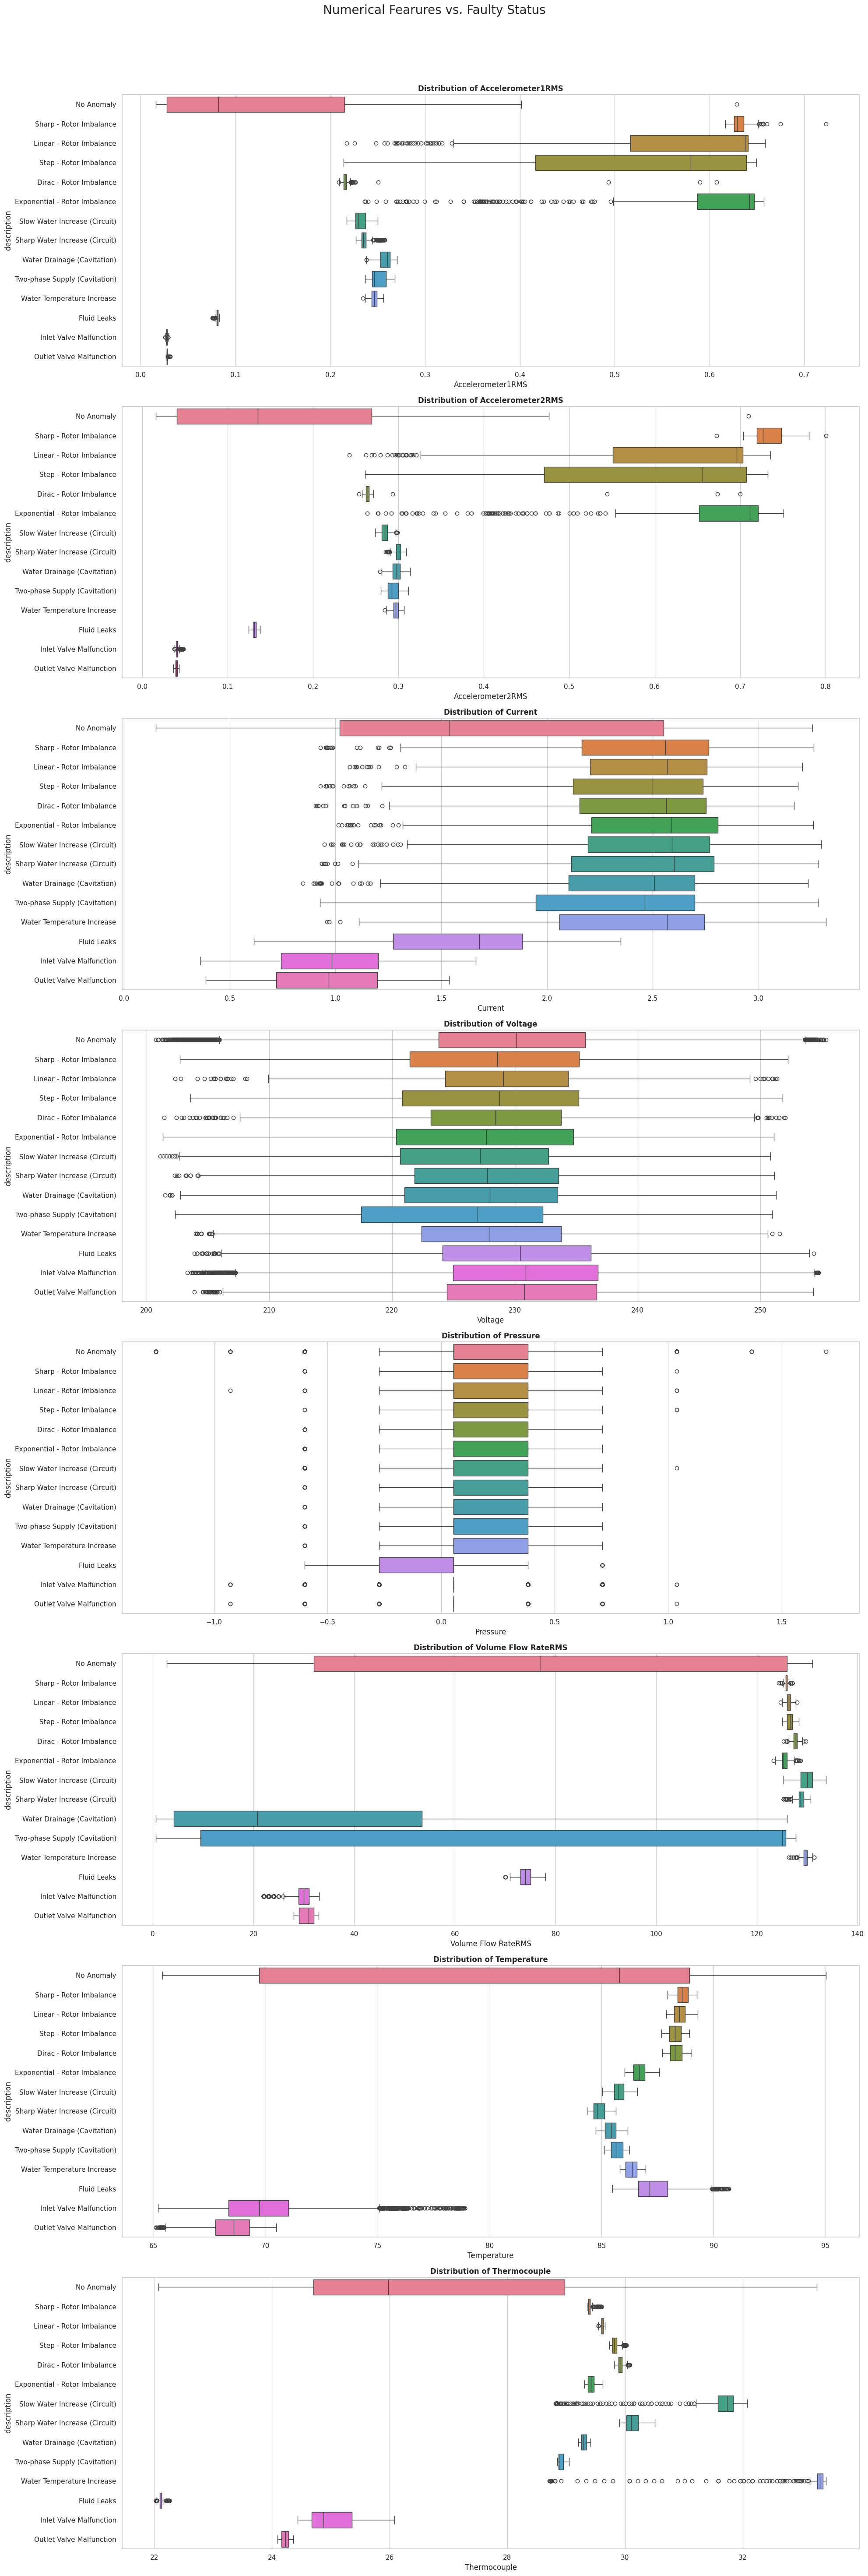

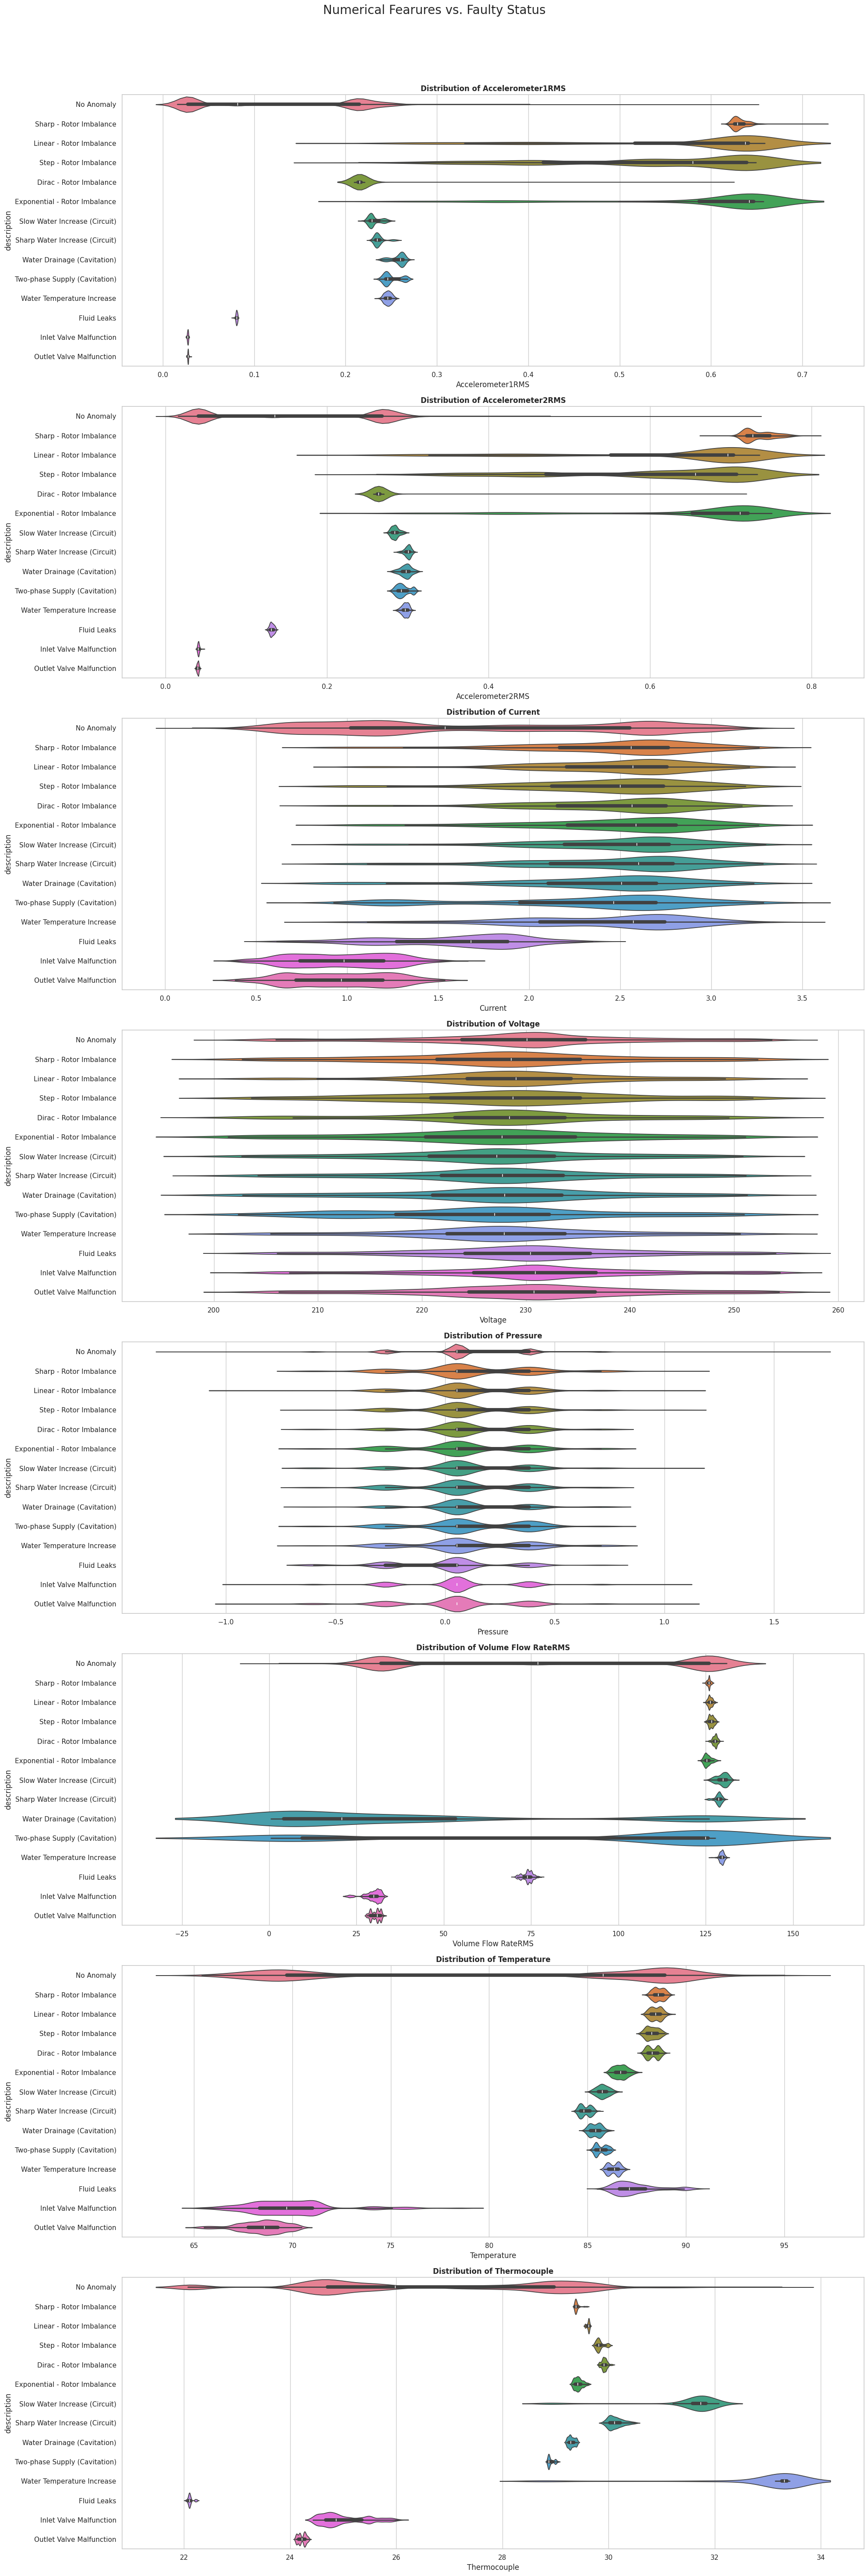

In [8]:
plot_box(dataframe, title="Numerical Fearures vs. Faulty Status")
plot_violin(dataframe, title="Numerical Fearures vs. Faulty Status")

In [9]:
def plot_anomaly_heatmap(df, columns, title=None):
    fig, axs = plt.subplots(7, 2, figsize=(20, 56), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.3)

    if title: plt.suptitle(title, fontsize=20)

    sns.heatmap(df.iloc[np.where(df.anomaly==0.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[0, 0])
    axs[0, 0].set_title("Heatmap of 'No Anomaly'")

    sns.heatmap(df.iloc[np.where(df.anomaly==1.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[0, 1])
    axs[0, 1].set_title("Heatmap of 'Sharp - Rotor Imbalance'")

    sns.heatmap(df.iloc[np.where(df.anomaly==2.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[1, 0])
    axs[1, 0].set_title("Heatmap of 'Linear - Rotor Imbalance'")

    sns.heatmap(df.iloc[np.where(df.anomaly==3.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[1, 1])
    axs[1, 1].set_title("Heatmap of 'Step - Rotor Imbalance'")

    sns.heatmap(df.iloc[np.where(df.anomaly==4.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[2, 0])
    axs[2, 0].set_title("Heatmap of 'Dirac - Rotor Imbalance'")

    sns.heatmap(df.iloc[np.where(df.anomaly==5.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[2, 1])
    axs[2, 1].set_title("Heatmap of 'Exponential - Rotor Imbalance'")

    sns.heatmap(df.iloc[np.where(df.anomaly==6.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[3, 0])
    axs[3, 0].set_title("Heatmap of 'Slow Water Increase (Circuit)'")

    sns.heatmap(df.iloc[np.where(df.anomaly==7.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[3, 1])
    axs[3, 1].set_title("Heatmap of 'Sharp Water Increase (Circuit)'")

    sns.heatmap(df.iloc[np.where(df.anomaly==8.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[4, 0])
    axs[4, 0].set_title("Heatmap of 'Water Drainage (Cavitation)'")

    sns.heatmap(df.iloc[np.where(df.anomaly==9.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[4, 1])
    axs[4, 1].set_title("Heatmap of 'Two-phase Supply (Cavitation)'")

    sns.heatmap(df.iloc[np.where(df.anomaly==10.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[5, 0])
    axs[5, 0].set_title("Heatmap of 'Water Temperature Increase'")

    sns.heatmap(df.iloc[np.where(df.anomaly==11.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[5, 1])
    axs[5, 1].set_title("Heatmap of 'Fluid Leaks'")

    sns.heatmap(df.iloc[np.where(df.anomaly==12.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[6, 0])
    axs[6, 0].set_title("Heatmap of 'Inlet Valve Malfunction'")

    sns.heatmap(df.iloc[np.where(df.anomaly==13.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[6, 1])
    axs[6, 1].set_title("Heatmap of 'Outlet Valve Malfunction'")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

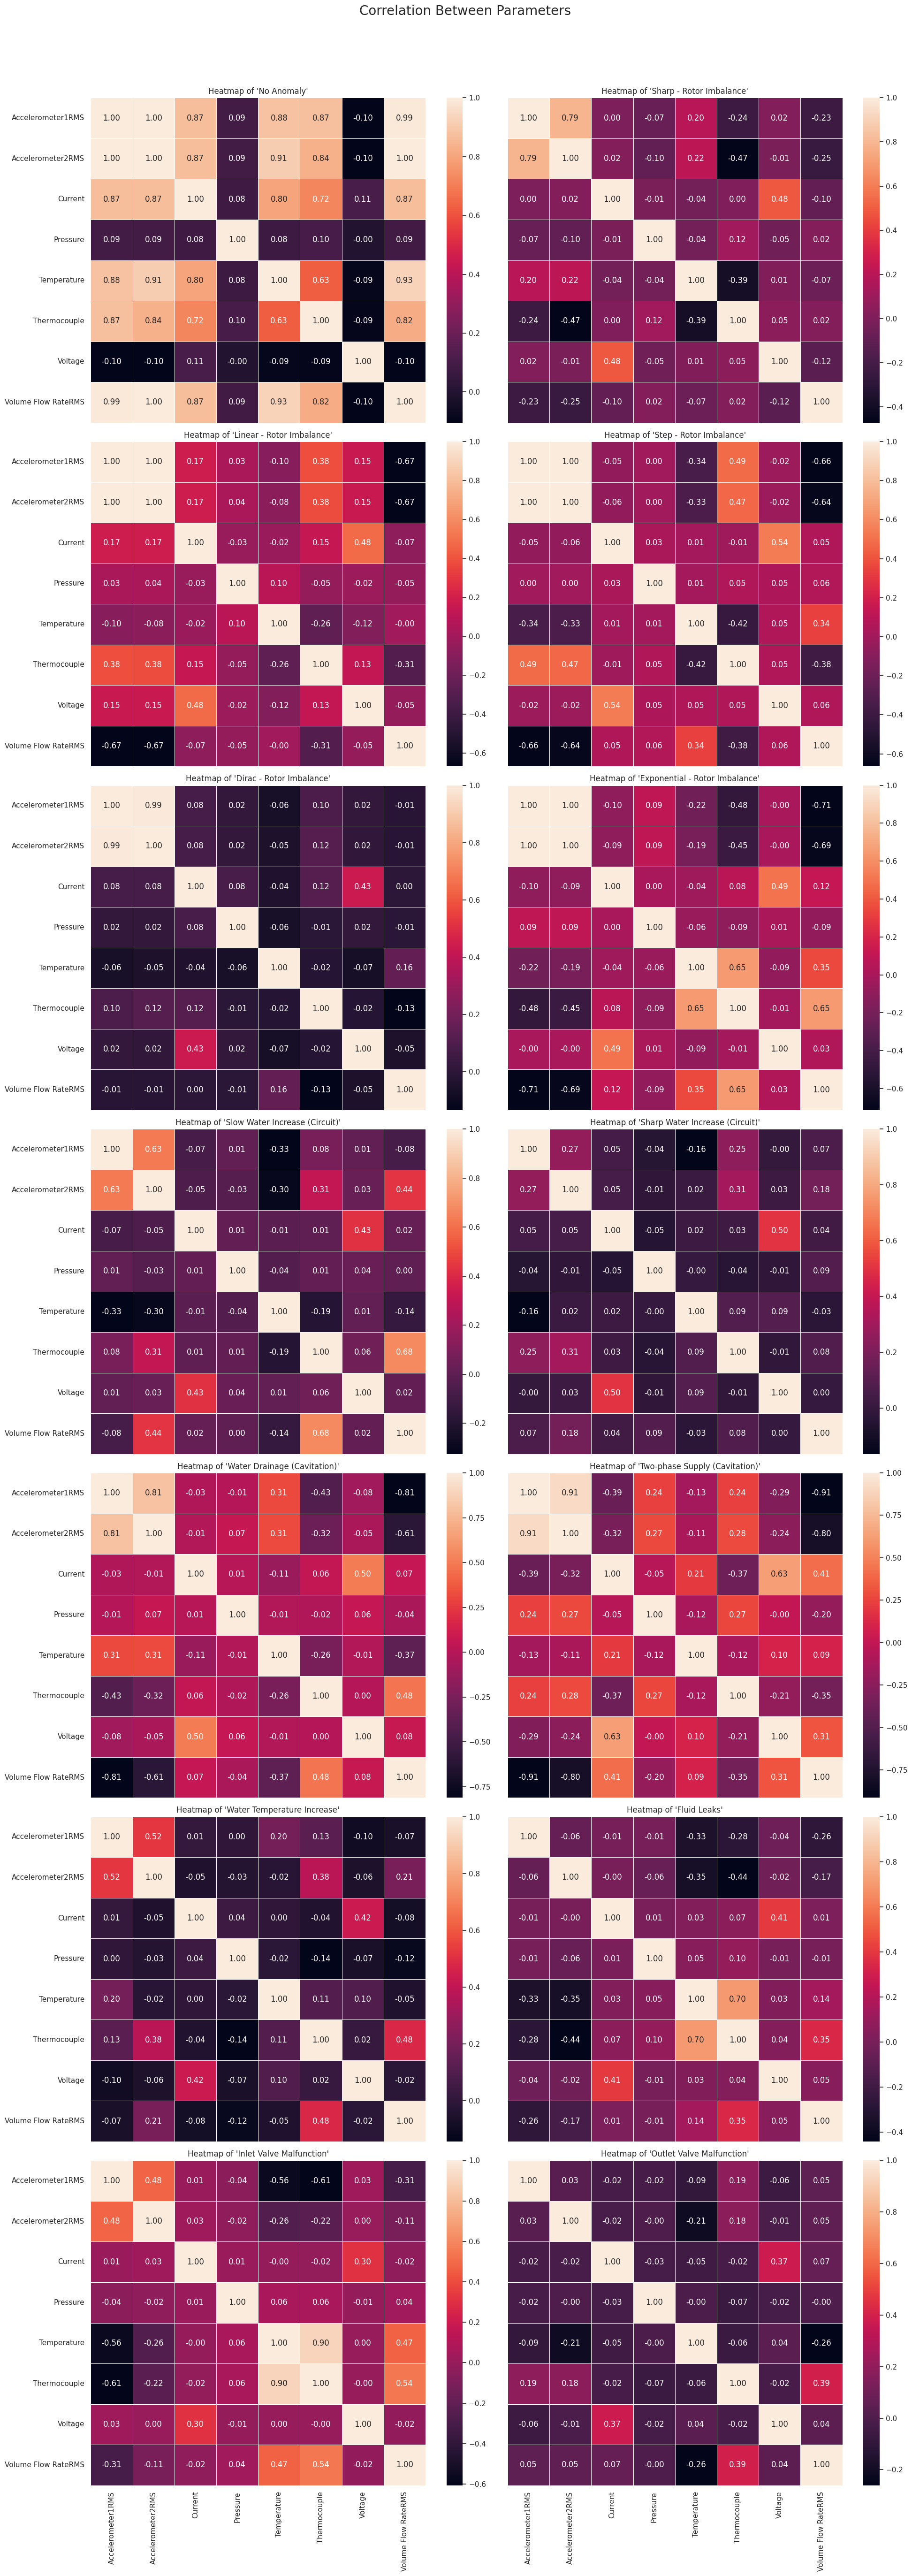

In [10]:
columns = [
            "Accelerometer1RMS", 
            "Accelerometer2RMS", 
            "Current", 
            "Pressure", 
            "Temperature", 
            "Thermocouple", 
            "Voltage", 
            "Volume Flow RateRMS",
]
plot_anomaly_heatmap(dataframe, columns, title="Correlation Between Parameters")

## Multivariate Analysis

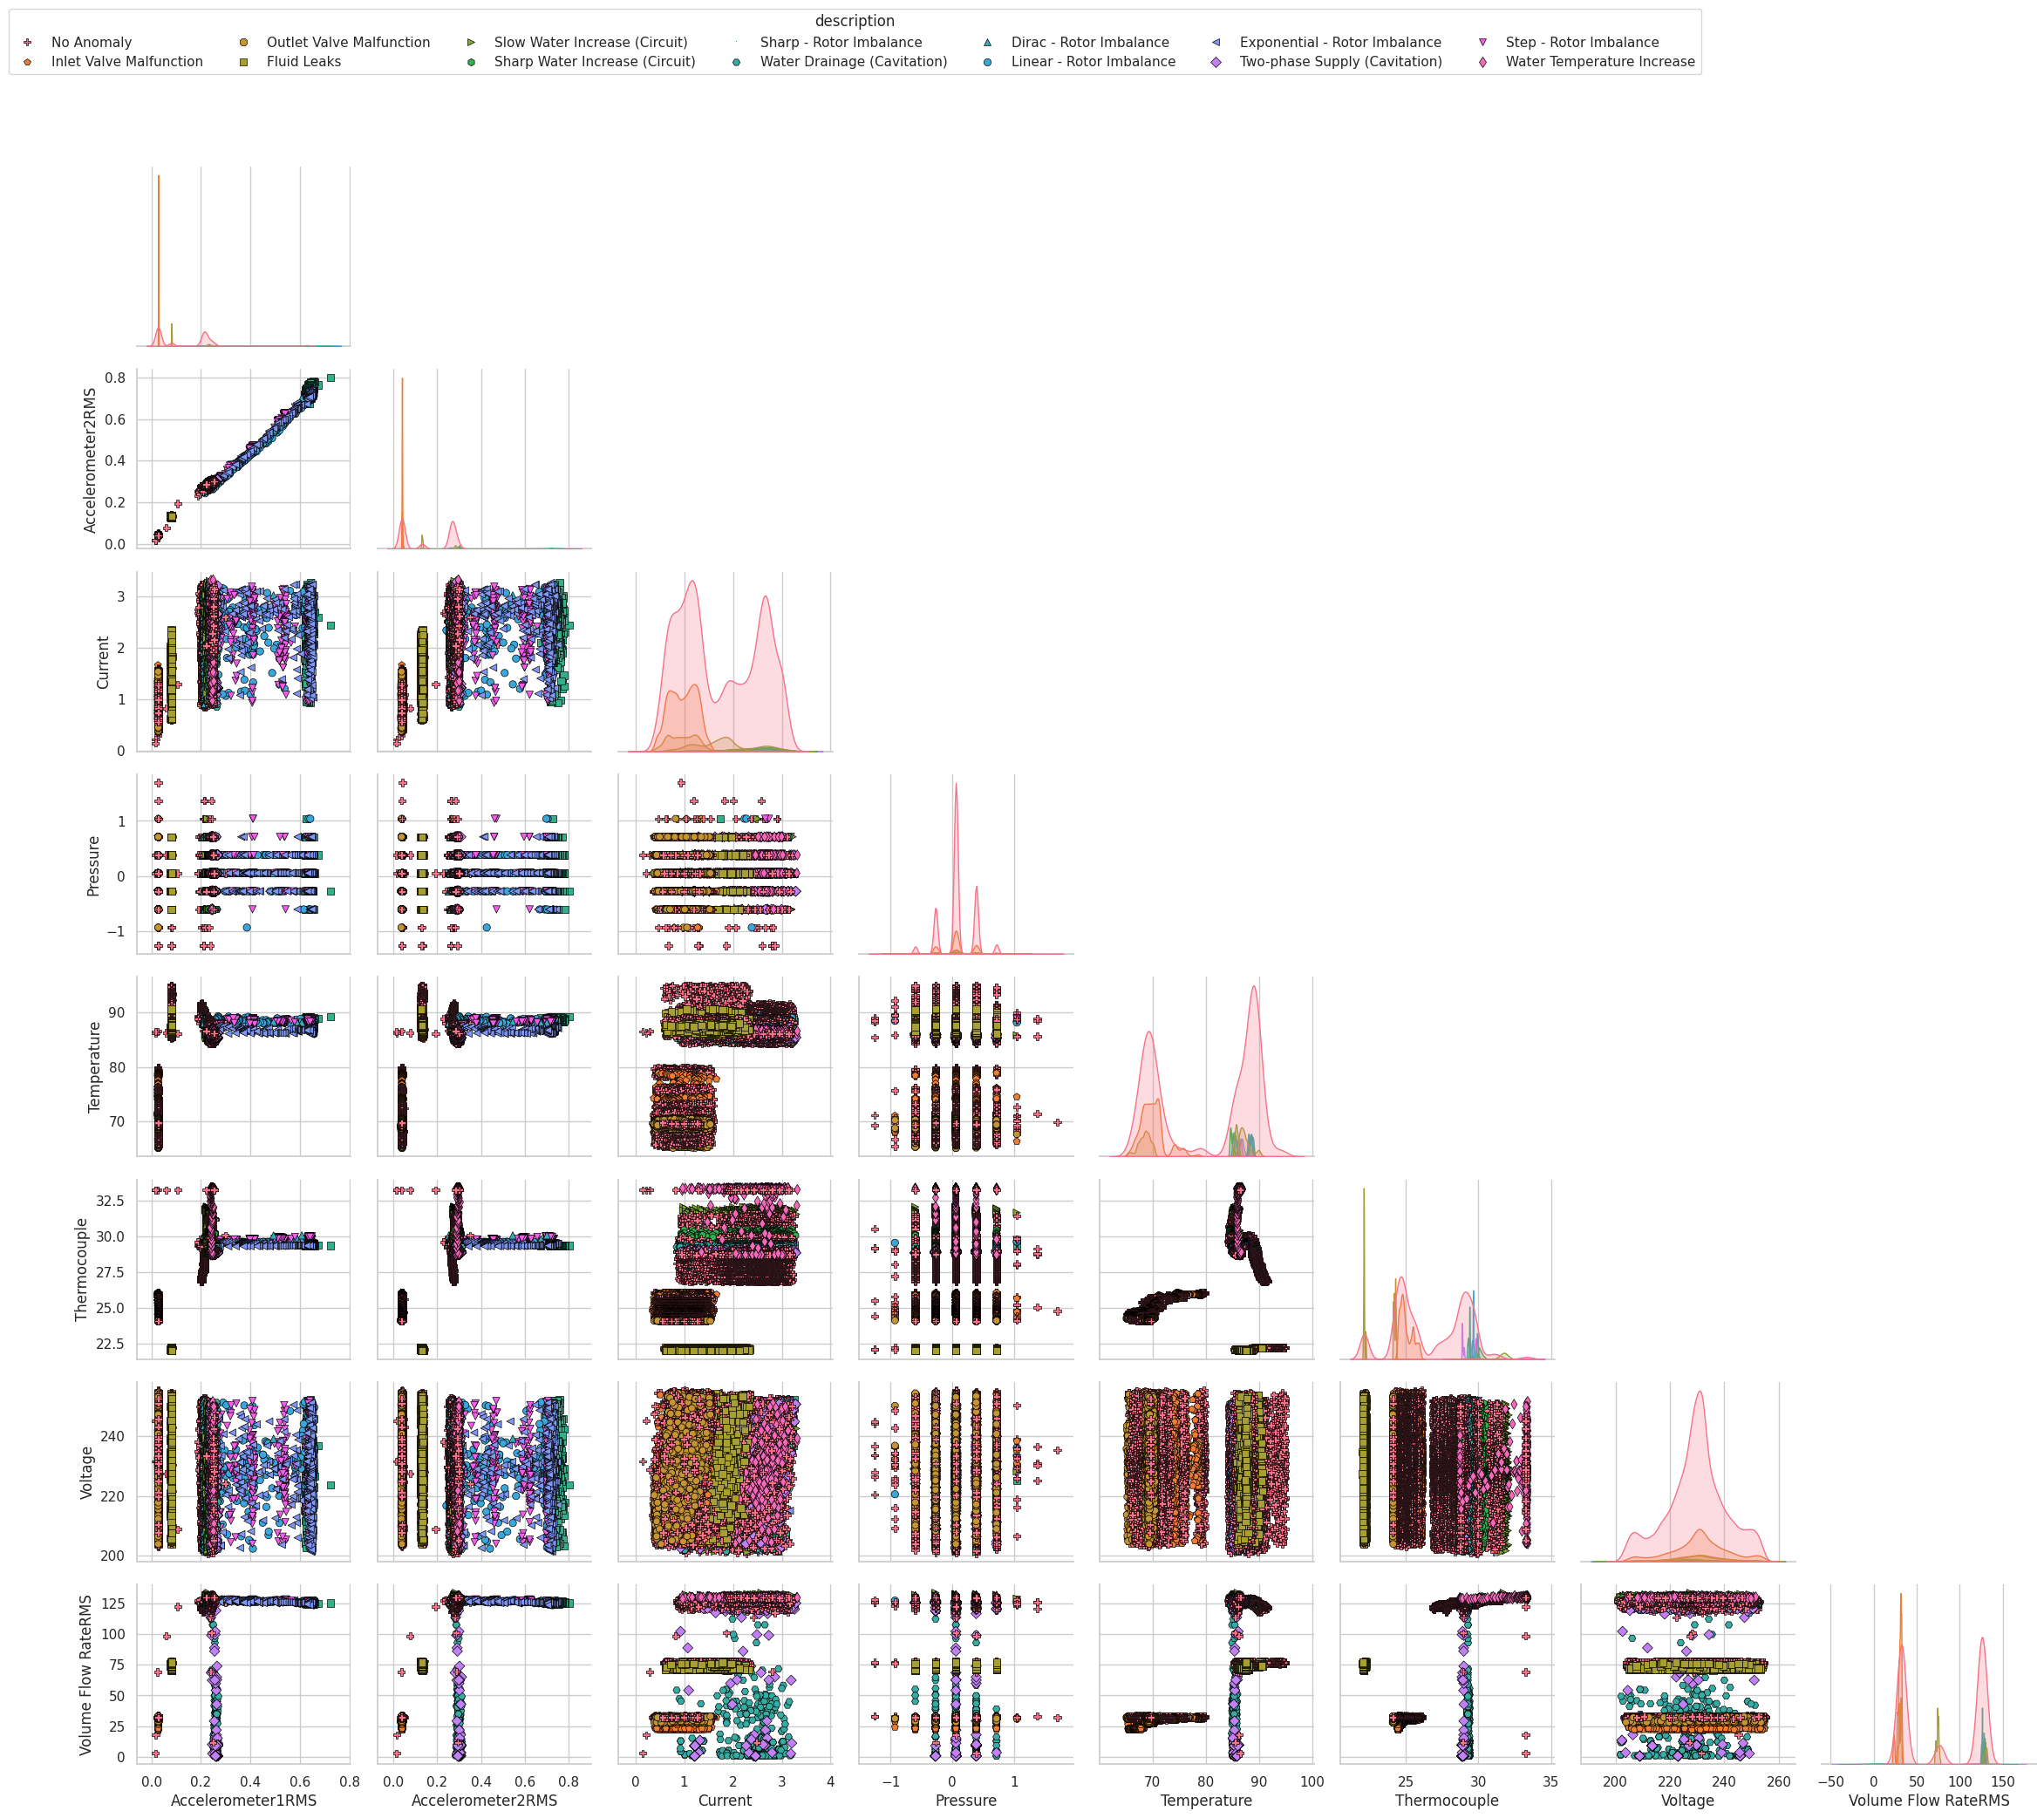

In [11]:
columns = [
            "Accelerometer1RMS", 
            "Accelerometer2RMS", 
            "Current", 
            "Pressure", 
            "Temperature", 
            "Thermocouple", 
            "Voltage", 
            "Volume Flow RateRMS",
]
ax = sns.pairplot(
                    data = dataframe, 
                    hue="description", 
                    hue_order=dataframe["description"].value_counts().index, 
                    vars=columns, 
                    corner=True, 
                    plot_kws={'edgecolor': 'black'},
                    markers=['P', ',', 'o', 'v', '^', '<', '>', 'h', 'H', 'D', 'd', 's', 'p', '8']
)
sns.move_legend(ax, "lower center", bbox_to_anchor=(.4, 1), ncol=7, title="description", frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
plt.show()

In [12]:
def plot_box2(df, xaxis, columns, hue=None, title=None):
    fig, axs = plt.subplots(len(columns), 1, figsize=(20, len(columns)*8), sharex=False)
    # plt.subplots_adjust(hspace=0.5)

    if title: plt.suptitle(title, fontsize=20) # Used suptitle for overall title

    for ax, yaxis in enumerate(columns):
        p = sns.boxplot(x=xaxis, y=yaxis, data=df, hue=hue, ax=axs[ax])
        axs[ax].set_title(f"Distribution of {yaxis}", weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()

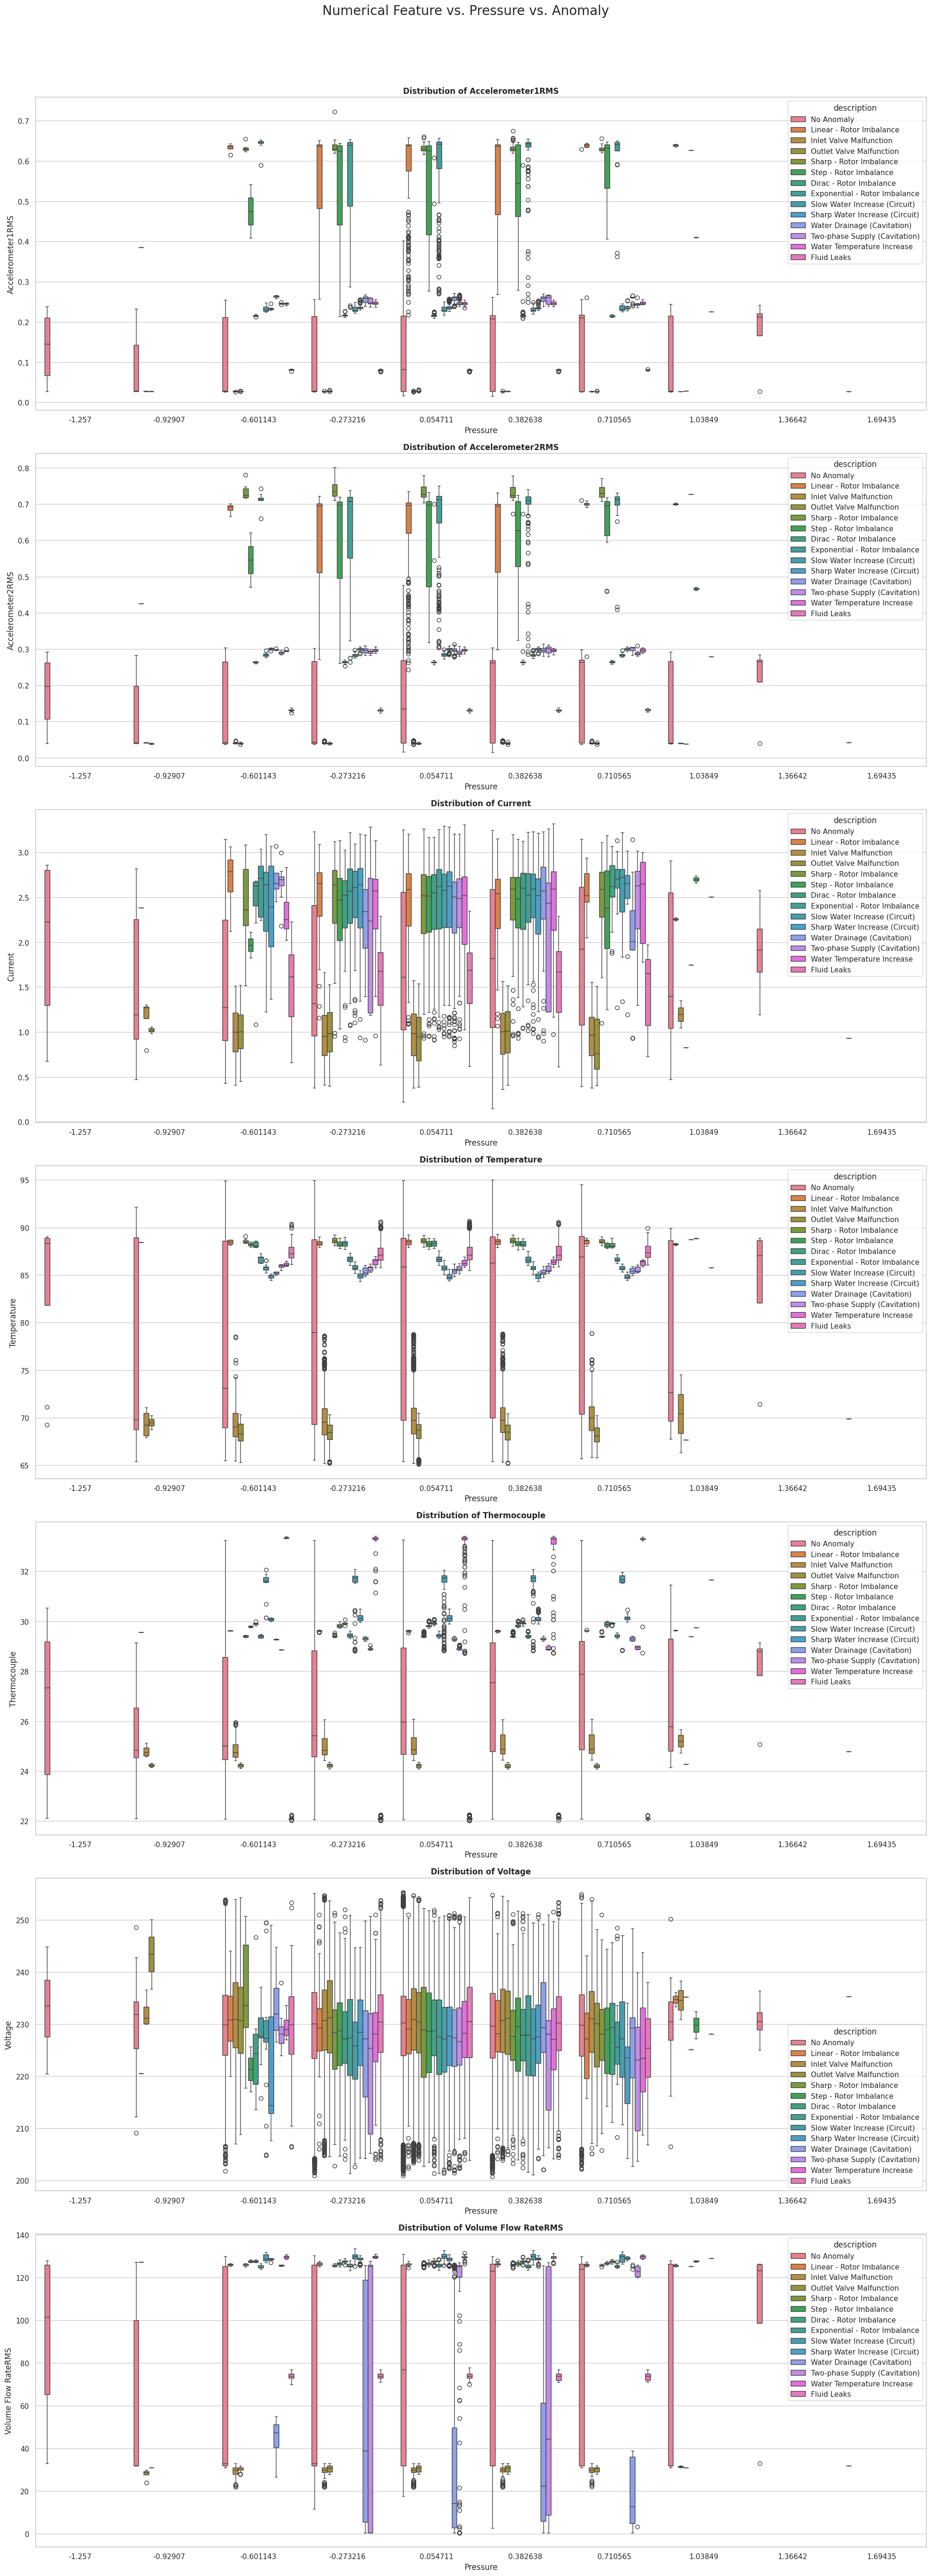

In [13]:
columns = [
            "Accelerometer1RMS", 
            "Accelerometer2RMS", 
            "Current", 
            # "Pressure", 
            "Temperature", 
            "Thermocouple", 
            "Voltage", 
            "Volume Flow RateRMS",
]   
plot_box2(dataframe, xaxis="Pressure", columns=columns, hue="description", title="Numerical Feature vs. Pressure vs. Anomaly")

In [ ]:
    # --- 6. Time Series Analysis (Optional) ---
    if 'timestamp' in df.columns:
        print("\n--- 6. Time Series Analysis ---")
        df_ts = df.set_index('timestamp')
        
        print("[INFO] Plotting vibration and temperature over time...")
        fig, ax1 = plt.subplots(figsize=(18, 7))
        
        # Plot vibration on primary y-axis
        color = 'tab:blue'
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Vibration', color=color)
        ax1.plot(df_ts.index, df_ts['vibration'], color=color, alpha=0.6, label='Vibration')
        ax1.tick_params(axis='y', labelcolor=color)

        # Create a second y-axis for temperature
        ax2 = ax1.twinx()
        color = 'tab:red'
        ax2.set_ylabel('Temperature (°C)', color=color)
        ax2.plot(df_ts.index, df_ts['temperature'], color=color, alpha=0.6, label='Temperature')
        ax2.tick_params(axis='y', labelcolor=color)

        # Highlight faulty points
        faulty_points = df_ts[df_ts[target] == 1]
        ax1.scatter(faulty_points.index, faulty_points['vibration'], color='black', s=50, zorder=5, label='Fault')

        fig.tight_layout()
        plt.title('Vibration and Temperature Over Time with Faults Highlighted')
        plt.legend()
        plt.show()

    print("\n--- Comprehensive EDA Complete ---")
